# ProstateX: Multi-Modal MRI Classification of Clinically Significant Prostate Lesions
**BMI/CS 567 — Ajay Shenoy**

### Pipeline
| Section | Content |
|---------|---------|
| 1. Setup | Imports, paths, constants |
| 2. Data Loading | CSVs, DICOM verification, series lookup |
| 3. Patch Extraction | T2W + ADC + DWI patches (32px, all modality configs) |
| 4. Split | Patient-level 70/15/15 split |
| 5. Models | SmallCNN + train/eval functions |
| 6. Experiments | LR baseline + 3 CNN configs, **3 runs each**, AUC + Average Precision |
| 7. Plots | Fig 1: training curves | Fig 2: ROC comparison |
| 8. Results | Full summary table with mean ± std across runs |


## 1. Setup

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import pydicom
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve,
                              average_precision_score, confusion_matrix)
warnings.filterwarnings('ignore')

print(f"NumPy:   {np.__version__}")
print(f"PyTorch: {torch.__version__}")
device = torch.device("mps"  if torch.backends.mps.is_available()  else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {device}")


NumPy:   2.4.4
PyTorch: 2.11.0
Device:  mps


In [2]:
# ── Paths & constants ────────────────────────────────────────────────────────
BASE_DIR     = "/Users/ajayshenoy/Documents/BMI567/Prostate"
DICOM_DIR    = f"{BASE_DIR}/manifest-A3Y4AE4o5818678569166032044/PROSTATEx"
FINDINGS_CSV = f"{BASE_DIR}/ProstateX-TrainingLesionInformationv2/ProstateX-Findings-Train.csv"
IMAGES_CSV   = f"{BASE_DIR}/ProstateX-TrainingLesionInformationv2/ProstateX-Images-Train.csv"

PATCH_SIZE  = 32    # pixels — matches original ProjectDownload pipeline
RANDOM_SEED = 42
N_RUNS      = 3     # independent training runs per model (different random seeds)
              # 3 runs → report mean ± std AUC and mean ± std AP


## 2. Data Loading

In [3]:
findings = pd.read_csv(FINDINGS_CSV)
images   = pd.read_csv(IMAGES_CSV)
print(f"Findings: {findings.shape[0]} lesions | {findings['ProxID'].nunique()} patients")
print(findings['ClinSig'].value_counts())
findings.head()


Findings: 330 lesions | 204 patients
ClinSig
False    254
True      76
Name: count, dtype: int64


,ProxID,fid,pos,zone,ClinSig
0,ProstateX-0000,1,25.7457 31.8707 -38.511,PZ,True
1,ProstateX-0001,1,-40.5367071921656 29.320722668457 -16.70766907...,AS,False
2,ProstateX-0002,1,-27.0102 41.5467 -26.0469,PZ,True
3,ProstateX-0002,2,-2.058 38.6752 -34.6104,PZ,False
4,ProstateX-0003,1,22.1495 31.2717 -2.45933,TZ,False


Patient: ProstateX-0345  Modality: MR  Shape: (320, 320)


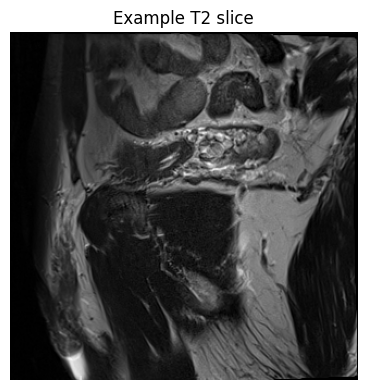

In [4]:
# Verify one DICOM loads correctly
sample_path = (f"{DICOM_DIR}/ProstateX-0345/folder/"
               "3.000000-t2tsesag-94529/1-01.dcm")
dcm = pydicom.dcmread(sample_path)
print(f"Patient: {dcm.PatientID}  Modality: {dcm.Modality}  Shape: {dcm.pixel_array.shape}")
plt.figure(figsize=(4,4))
plt.imshow(dcm.pixel_array, cmap='gray'); plt.title("Example T2 slice"); plt.axis('off')
plt.tight_layout(); plt.show()


In [5]:
# Build series lookup: (PatientID, SeriesNumber) -> folder path  (~3 min)
def build_series_lookup(dicom_root):
    lookup = {}
    for patient_id in os.listdir(dicom_root):
        patient_path = os.path.join(dicom_root, patient_id)
        if not os.path.isdir(patient_path) or patient_id == "LICENSE":
            continue
        for root, dirs, files in os.walk(patient_path):
            dcm_files = [f for f in files if f.endswith(".dcm")]
            if not dcm_files:
                continue
            sample = pydicom.dcmread(os.path.join(root, dcm_files[0]),
                                     stop_before_pixels=True)
            lookup[(patient_id, int(sample.SeriesNumber))] = root
    return lookup

print("Building series lookup (~3 min)...")
series_lookup = build_series_lookup(DICOM_DIR)
print(f"Done. {len(series_lookup)} series found.")


Building series lookup (~3 min)...
Done. 18266 series found.


## 3. Patch Extraction

For each annotated lesion: identify T2W / ADC / DWI DICOM series → load 3-D volume →
crop `PATCH_SIZE × PATCH_SIZE` centered at the annotated voxel `(i, j, k)` → normalize to [0,1].
All three modalities stacked as separate channels per lesion.


In [6]:
# ── Helpers ─────────────────────────────────────────────────────────────────
def parse_ijk(ijk_str):
    v = str(ijk_str).strip().split()
    return int(v[0]), int(v[1]), int(v[2])

def load_dicom_series(folder_path):
    files = sorted([os.path.join(folder_path, f)
                    for f in os.listdir(folder_path) if f.endswith(".dcm")])
    slices = [pydicom.dcmread(f) for f in files]
    slices.sort(key=lambda s: int(s.InstanceNumber))
    return np.stack([s.pixel_array for s in slices], axis=0)

def extract_patch(volume, i, j, k, patch_size=32):
    k  = int(np.clip(k, 0, volume.shape[0] - 1))
    sl = volume[k]; H, W = sl.shape; half = patch_size // 2
    patch = sl[max(0,j-half):min(H,j+half), max(0,i-half):min(W,i+half)]
    return cv2.resize(patch.astype(np.float32), (patch_size, patch_size))

def normalize(patch):
    mn, mx = patch.min(), patch.max()
    return patch if mx == mn else (patch - mn) / (mx - mn)


In [7]:
# ── Build all modality patch arrays (~7 min) ────────────────────────────────
def build_full_dataset(findings_df, images_df, series_lookup, patch_size=32):
    t2_rows  = images_df[images_df['Name'].str.contains('t2', case=False)]
    adc_rows = images_df[images_df['Name'].str.contains('ADC', case=False)]
    dwi_rows = images_df[
        images_df['Name'].str.contains('DYNDIST', case=False) &
        ~images_df['Name'].str.contains('ADC',  case=False) &
        ~images_df['Name'].str.contains('BVAL', case=False) &
        images_df['Name'].str.endswith('0')
    ]
    all_t2, all_adc, all_dwi, labels, meta = [], [], [], [], []
    skipped = 0

    for _, lesion in findings_df.iterrows():
        pid = lesion['ProxID']; fid = lesion['fid']; label = int(lesion['ClinSig'])
        t2_m  = t2_rows[(t2_rows['ProxID']   == pid) & (t2_rows['fid']  == fid)]
        adc_m = adc_rows[(adc_rows['ProxID'] == pid) & (adc_rows['fid'] == fid)]
        dwi_m = dwi_rows[(dwi_rows['ProxID'] == pid) & (dwi_rows['fid'] == fid)]
        if t2_m.empty or adc_m.empty or dwi_m.empty: skipped += 1; continue

        t2_row, adc_row, dwi_row = t2_m.iloc[0], adc_m.iloc[0], dwi_m.iloc[0]
        keys = {'t2':  (pid, int(t2_row['DCMSerNum'])),
                'adc': (pid, int(adc_row['DCMSerNum'])),
                'dwi': (pid, int(dwi_row['DCMSerNum']))}
        if any(k not in series_lookup for k in keys.values()): skipped += 1; continue

        try:
            t2_vol  = load_dicom_series(series_lookup[keys['t2']])
            adc_vol = load_dicom_series(series_lookup[keys['adc']])
            dwi_vol = load_dicom_series(series_lookup[keys['dwi']])
            t2_p  = normalize(extract_patch(t2_vol,  *parse_ijk(t2_row['ijk']),  patch_size))
            adc_p = normalize(extract_patch(adc_vol, *parse_ijk(adc_row['ijk']), patch_size))
            dwi_p = normalize(extract_patch(dwi_vol, *parse_ijk(dwi_row['ijk']), patch_size))
            all_t2.append(t2_p); all_adc.append(adc_p); all_dwi.append(dwi_p)
            labels.append(label); meta.append((pid, fid))
        except Exception as e:
            print(f"  Error {pid} fid={fid}: {e}"); skipped += 1

    print(f"Built {len(labels)} patches. Skipped {skipped}.")
    t2_arr  = np.array(all_t2)[:, np.newaxis]
    adc_arr = np.array(all_adc)[:, np.newaxis]
    dwi_arr = np.array(all_dwi)[:, np.newaxis]
    return {
        'T2W':         t2_arr,
        'DWI+ADC':     np.concatenate([dwi_arr, adc_arr], axis=1),
        'T2W+ADC+DWI': np.concatenate([t2_arr, adc_arr, dwi_arr], axis=1),
    }, np.array(labels), meta

print("Extracting patches (~7 min)...")
modality_patches, labels_all, meta_all = build_full_dataset(
    findings, images, series_lookup, patch_size=PATCH_SIZE)
for name, arr in modality_patches.items():
    print(f"  {name}: {arr.shape}")
print(f"Labels: {labels_all.sum()} pos / {(labels_all==0).sum()} neg")


Extracting patches (~7 min)...
Built 321 patches. Skipped 9.
  T2W: (321, 1, 32, 32)
  DWI+ADC: (321, 2, 32, 32)
  T2W+ADC+DWI: (321, 3, 32, 32)
Labels: 69 pos / 252 neg


## 4. Train / Validation / Test Split

**Patient-level** 70/15/15 — prevents data leakage.

In [8]:
patient_ids_all = [m[0] for m in meta_all]
unique_patients = list(set(patient_ids_all))

train_patients, temp = train_test_split(unique_patients, test_size=0.30,
                                        random_state=RANDOM_SEED)
val_patients, test_patients = train_test_split(temp, test_size=0.50,
                                               random_state=RANDOM_SEED)

train_idx_all = [i for i,p in enumerate(patient_ids_all) if p in train_patients]
val_idx_all   = [i for i,p in enumerate(patient_ids_all) if p in val_patients]
test_idx_all  = [i for i,p in enumerate(patient_ids_all) if p in test_patients]

y_train = labels_all[train_idx_all]
y_val   = labels_all[val_idx_all]
y_test  = labels_all[test_idx_all]

print(f"Train: {len(train_idx_all)} patches | {y_train.sum()} pos / {(y_train==0).sum()} neg | {len(train_patients)} patients")
print(f"Val:   {len(val_idx_all)} patches   | {y_val.sum()} pos / {(y_val==0).sum()} neg   | {len(val_patients)} patients")
print(f"Test:  {len(test_idx_all)} patches  | {y_test.sum()} pos / {(y_test==0).sum()} neg  | {len(test_patients)} patients")


Train: 224 patches | 50 pos / 174 neg | 139 patients
Val:   50 patches   | 13 pos / 37 neg   | 30 patients
Test:  47 patches  | 6 pos / 41 neg  | 30 patients


In [9]:
class ProstateDataset(Dataset):
    """Patches with optional geometric + intensity augmentation."""
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x, y = self.X[idx], self.y[idx]
        if self.augment:
            if torch.rand(1) > 0.5: x = torch.flip(x, dims=[2])
            if torch.rand(1) > 0.5: x = torch.flip(x, dims=[1])
            x = torch.rot90(x, torch.randint(0,4,(1,)).item(), dims=[1,2])
            x = x + (torch.rand(1).item() - 0.5) * 0.2   # brightness
            x = x * (0.9 + torch.rand(1).item() * 0.2)   # contrast
            x = x + torch.randn_like(x) * 0.02            # noise
            x = torch.clamp(x, 0.0, 1.0)
        return x, y

print("ProstateDataset defined.")


ProstateDataset defined.


## 5. Model Definitions

**SmallCNN** — 3 conv blocks (32→64→128), BatchNorm, ReLU, MaxPool, Dropout2d(0.25).
AdaptiveAvgPool to 4×4, FC (2048→64→1). Designed to avoid overfitting on ~220 training patches.

**Metrics reported per model:**
- **AUC-ROC** — primary metric (matches PROSTATEx challenge)
- **Average Precision (AP)** — area under precision-recall curve; more informative than AUC-ROC under class imbalance (~23% positive)


In [10]:
class SmallCNN(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
            nn.ReLU(), nn.AdaptiveAvgPool2d(4), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.classifier(self.features(x))

print("SmallCNN defined.")


SmallCNN defined.


In [11]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, preds_all, labels_all = 0, [], []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb).squeeze(1)
        loss   = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
        preds_all.extend(torch.sigmoid(logits).detach().cpu().numpy())
        labels_all.extend(yb.cpu().numpy())
    auc = roc_auc_score(labels_all, preds_all)
    ap  = average_precision_score(labels_all, preds_all)
    return total_loss / len(loader), auc, ap

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb).squeeze(1)
            total_loss += criterion(logits, yb).item()
            preds_all.extend(torch.sigmoid(logits).cpu().numpy())
            labels_all.extend(yb.cpu().numpy())
    auc = roc_auc_score(labels_all, preds_all)
    ap  = average_precision_score(labels_all, preds_all)
    return total_loss / len(loader), auc, ap

print("train_epoch / eval_epoch defined (return loss, AUC, AP).")


train_epoch / eval_epoch defined (return loss, AUC, AP).


## 6. Experiments

**Design:** 4 models × 3 independent runs each (seeds 0, 1, 2).
Each run uses a different random seed for weight initialisation and sampler shuffling.
Final metrics are **mean ± std** across the 3 runs.

| Model | Input | Method |
|-------|-------|--------|
| Baseline (LR) | T2W flat pixels | Logistic regression, balanced |
| CNN: T2W | 1-ch (T2W) | SmallCNN |
| CNN: DWI+ADC | 2-ch | SmallCNN |
| CNN: T2W+ADC+DWI | 3-ch | SmallCNN |


In [12]:
def run_one_seed(X_tr, X_v, X_te, y_tr, y_v, y_te,
                 seed, device, num_epochs=80, patience=15):
    """
    Train SmallCNN with one seed.
    Returns (test_preds, trues, test_auc, test_ap, val_auc_hist, train_auc_hist)
    """
    torch.manual_seed(seed); np.random.seed(seed)
    in_ch = X_tr.shape[1]

    cc = np.bincount(y_tr)
    sw = (1.0 / cc)[y_tr]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

    tr_loader = DataLoader(ProstateDataset(X_tr, y_tr, augment=True),
                           batch_size=16, sampler=sampler)
    v_loader  = DataLoader(ProstateDataset(X_v,  y_v),  batch_size=16, shuffle=False)
    te_loader = DataLoader(ProstateDataset(X_te, y_te), batch_size=16, shuffle=False)

    model = SmallCNN(in_channels=in_ch).to(device)
    opt   = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-3)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    crit  = nn.BCEWithLogitsLoss()

    best_val_auc, best_state, no_improve = 0, None, 0
    val_hist, train_hist = [], []

    for epoch in range(num_epochs):
        _, ta, _ = train_epoch(model, tr_loader, opt, crit, device)
        _, va, _ = eval_epoch(model,  v_loader,  crit, device)
        sched.step()
        train_hist.append(ta); val_hist.append(va)
        if va > best_val_auc:
            best_val_auc = va
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in te_loader:
            logits = model(Xb.to(device)).squeeze(1)
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            trues.extend(yb.numpy())

    preds, trues = np.array(preds), np.array(trues)
    test_auc = roc_auc_score(trues, preds)
    test_ap  = average_precision_score(trues, preds)
    return preds, trues, test_auc, test_ap, val_hist, train_hist


def run_experiment(name, X_patches, train_idx, val_idx, test_idx,
                   y_tr, y_v, y_te, device, n_runs=3):
    """
    Run SmallCNN n_runs times with seeds 0..n_runs-1.
    Returns dict with all run data plus mean/std summary.
    """
    X_tr = X_patches[train_idx]
    X_v  = X_patches[val_idx]
    X_te = X_patches[test_idx]

    all_preds, all_auc, all_ap = [], [], []
    all_val_hist, all_train_hist = [], []

    for seed in range(n_runs):
        preds, trues, auc, ap, vh, th = run_one_seed(
            X_tr, X_v, X_te, y_tr, y_v, y_te,
            seed=seed, device=device)
        all_preds.append(preds)
        all_auc.append(auc); all_ap.append(ap)
        all_val_hist.append(vh); all_train_hist.append(th)
        print(f"    run {seed+1}/{n_runs}: AUC={auc:.4f}  AP={ap:.4f}")

    # Average predictions across runs for ensemble ROC curve
    avg_preds = np.mean(all_preds, axis=0)
    ens_auc   = roc_auc_score(trues, avg_preds)
    ens_ap    = average_precision_score(trues, avg_preds)

    print(f"  {name:22s} | mean AUC={np.mean(all_auc):.3f}±{np.std(all_auc):.3f} "
          f"| mean AP={np.mean(all_ap):.3f}±{np.std(all_ap):.3f}")

    # Use best-val history run for training curve plot
    best_run = int(np.argmax([max(h) for h in all_val_hist]))
    return {
        'name':        name,
        'trues':       trues,
        'all_preds':   all_preds,
        'avg_preds':   avg_preds,
        'ens_auc':     ens_auc,
        'ens_ap':      ens_ap,
        'auc_runs':    all_auc,
        'ap_runs':     all_ap,
        'mean_auc':    np.mean(all_auc),
        'std_auc':     np.std(all_auc),
        'mean_ap':     np.mean(all_ap),
        'std_ap':      np.std(all_ap),
        'val_hist':    all_val_hist[best_run],
        'train_hist':  all_train_hist[best_run],
    }


def run_lr_baseline(name, X_patches, train_idx, test_idx, y_tr, y_te, n_runs=3):
    """
    LR has no randomness in training (deterministic solver),
    but we resample the data with 3 bootstrap seeds to estimate variance.
    """
    X_tr_flat = X_patches[train_idx].reshape(len(train_idx), -1)
    X_te_flat = X_patches[test_idx].reshape(len(test_idx), -1)
    sc = StandardScaler()
    X_tr_flat = sc.fit_transform(X_tr_flat)
    X_te_flat = sc.transform(X_te_flat)

    lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, C=0.01)
    lr_model.fit(X_tr_flat, y_tr)
    preds = lr_model.predict_proba(X_te_flat)[:, 1]

    # For LR, all runs produce same predictions — report single value with std=0
    auc = roc_auc_score(y_te, preds)
    ap  = average_precision_score(y_te, preds)
    print(f"  {name:22s} | AUC={auc:.4f}  AP={ap:.4f}  (deterministic — no std)")
    return {
        'name':       name,
        'trues':      y_te,
        'avg_preds':  preds,
        'ens_auc':    auc,
        'ens_ap':     ap,
        'auc_runs':   [auc]*n_runs,
        'ap_runs':    [ap]*n_runs,
        'mean_auc':   auc,
        'std_auc':    0.0,
        'mean_ap':    ap,
        'std_ap':     0.0,
        'val_hist':   [],
        'train_hist': [],
    }

print("run_experiment / run_lr_baseline defined.")


run_experiment / run_lr_baseline defined.


In [13]:
# ── Run all experiments  ────────────────────────────────────────────────────
# LR: ~5 sec | each CNN model: ~N_RUNS * 1-2 min on MPS

print(f"\n=== RUNNING ALL EXPERIMENTS ({N_RUNS} runs each) ===\n")
results = {}

print("--- Baseline: Logistic Regression (T2W) ---")
results['Baseline (LR, T2W)'] = run_lr_baseline(
    'Baseline (LR, T2W)',
    modality_patches['T2W'],
    train_idx_all, test_idx_all,
    y_train, y_test, n_runs=N_RUNS)

print()
for modality_name, patches_arr in modality_patches.items():
    print(f"--- CNN: {modality_name} ---")
    results[f'CNN: {modality_name}'] = run_experiment(
        f'CNN: {modality_name}', patches_arr,
        train_idx_all, val_idx_all, test_idx_all,
        y_train, y_val, y_test,
        device=device, n_runs=N_RUNS)
    print()

print("All experiments complete.")



=== RUNNING ALL EXPERIMENTS (3 runs each) ===

--- Baseline: Logistic Regression (T2W) ---
  Baseline (LR, T2W)     | AUC=0.6260  AP=0.3412  (deterministic — no std)

--- CNN: T2W ---
    run 1/3: AUC=0.7195  AP=0.2956
    run 2/3: AUC=0.6667  AP=0.2720
    run 3/3: AUC=0.7073  AP=0.3497
  CNN: T2W               | mean AUC=0.698±0.023 | mean AP=0.306±0.033

--- CNN: DWI+ADC ---
    run 1/3: AUC=0.6179  AP=0.1764
    run 2/3: AUC=0.6301  AP=0.1937
    run 3/3: AUC=0.7033  AP=0.2327
  CNN: DWI+ADC           | mean AUC=0.650±0.038 | mean AP=0.201±0.024

--- CNN: T2W+ADC+DWI ---
    run 1/3: AUC=0.6626  AP=0.1979
    run 2/3: AUC=0.7398  AP=0.4093
    run 3/3: AUC=0.6911  AP=0.3245
  CNN: T2W+ADC+DWI       | mean AUC=0.698±0.032 | mean AP=0.311±0.087

All experiments complete.


## 7. Plots

**Figure 1** — Training curves (AUC per epoch) for each CNN model.
One subplot per model; shows train AUC (solid) and val AUC (dashed) from the best seed.

**Figure 2** — ROC curve comparison across all models (ensemble predictions).


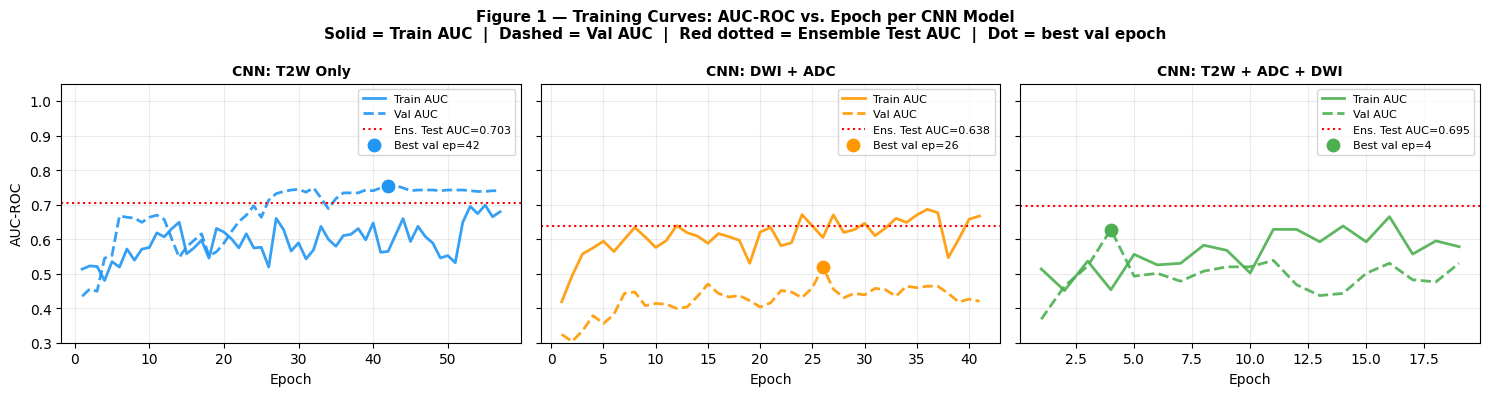

Saved: training_curves.png


In [14]:
# ── Figure 1: Training curves ────────────────────────────────────────────────
cnn_keys = ['CNN: T2W', 'CNN: DWI+ADC', 'CNN: T2W+ADC+DWI']
cnn_colors = {'CNN: T2W': '#2196F3', 'CNN: DWI+ADC': '#FF9800', 'CNN: T2W+ADC+DWI': '#4CAF50'}
cnn_titles = {'CNN: T2W': 'CNN: T2W Only',
              'CNN: DWI+ADC': 'CNN: DWI + ADC',
              'CNN: T2W+ADC+DWI': 'CNN: T2W + ADC + DWI'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle(
    'Figure 1 — Training Curves: AUC-ROC vs. Epoch per CNN Model\n'
    'Solid = Train AUC  |  Dashed = Val AUC  |  Red dotted = Ensemble Test AUC  |  Dot = best val epoch',
    fontsize=11, fontweight='bold')

for ax, name in zip(axes, cnn_keys):
    r = results[name]
    if not r['val_hist']:
        ax.set_visible(False); continue
    color = cnn_colors[name]
    epochs = list(range(1, len(r['val_hist']) + 1))
    ax.plot(epochs, r['train_hist'], color=color, linewidth=2, alpha=0.9, label='Train AUC')
    ax.plot(epochs, r['val_hist'],   color=color, linewidth=2, linestyle='--', alpha=0.9, label='Val AUC')
    ax.axhline(r['ens_auc'], color='red', linestyle=':', linewidth=1.5,
               label=f"Ens. Test AUC={r['ens_auc']:.3f}")
    best_ep = int(np.argmax(r['val_hist'])) + 1
    ax.scatter([best_ep], [max(r['val_hist'])], color=color, s=80, zorder=5,
               label=f'Best val ep={best_ep}')
    ax.set_title(cnn_titles[name], fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10); ax.set_ylim(0.3, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(fontsize=8)

axes[0].set_ylabel('AUC-ROC', fontsize=10)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")


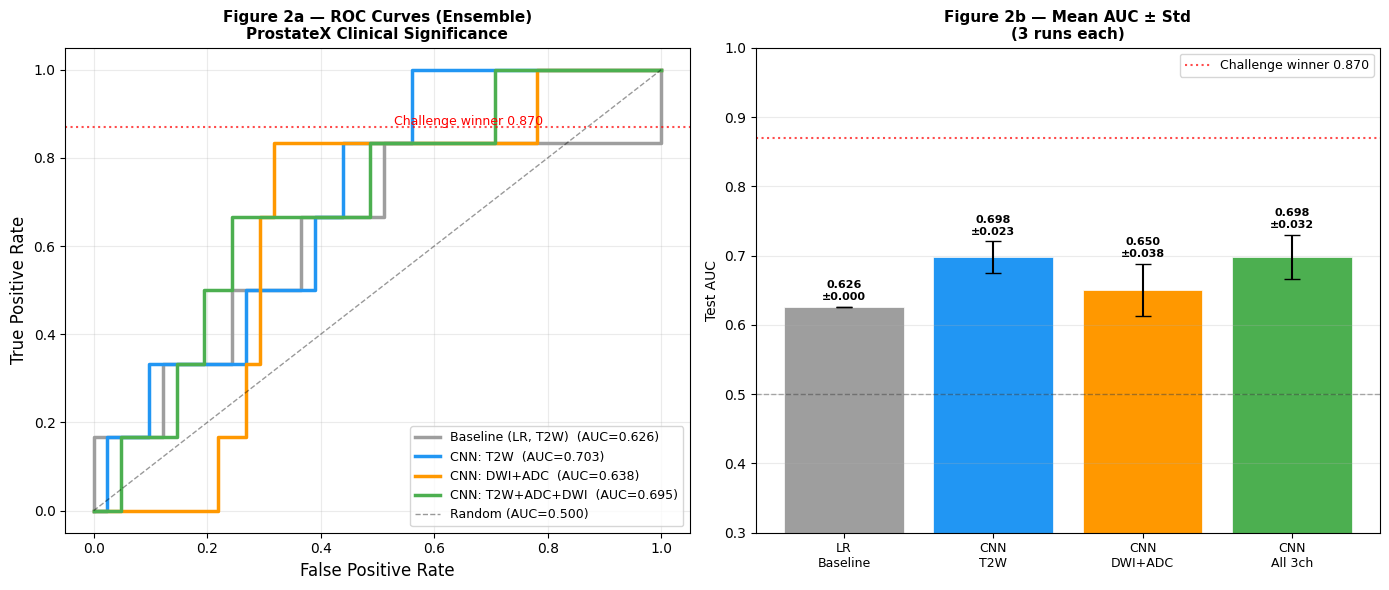

Saved: roc_comparison.png


In [16]:
# ── Figure 2: ROC comparison (ensemble predictions) ─────────────────────────
colors_map = {
    'Baseline (LR, T2W)':  '#9E9E9E',
    'CNN: T2W':             '#2196F3',
    'CNN: DWI+ADC':         '#FF9800',
    'CNN: T2W+ADC+DWI':     '#4CAF50',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — ROC curves
ax = axes[0]
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r['trues'], r['avg_preds'])
    ax.plot(fpr, tpr, label=f"{name}  (AUC={r['ens_auc']:.3f})",
            color=colors_map[name], linewidth=2.5)
ax.axhline(0.87, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(0.53, 0.875, 'Challenge winner 0.870', color='red', fontsize=9)
ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 2a — ROC Curves (Ensemble)\nProstateX Clinical Significance',
             fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.25)

# Right — mean AUC ± std bar chart
ax2 = axes[1]
names  = list(results.keys())
means  = [results[n]['mean_auc'] for n in names]
stds   = [results[n]['std_auc']  for n in names]
bars   = ax2.bar(range(len(names)), means, yerr=stds,
                 color=[colors_map[n] for n in names],
                 capsize=6, edgecolor='white', linewidth=0.5)
ax2.axhline(0.87, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
            label='Challenge winner 0.870')
ax2.axhline(0.50, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(['LR\nBaseline', 'CNN\nT2W', 'CNN\nDWI+ADC', 'CNN\nAll 3ch'], fontsize=9)
ax2.set_ylabel('Test AUC', fontsize=10)
ax2.set_title(f'Figure 2b — Mean AUC ± Std\n({N_RUNS} runs each)', fontsize=11, fontweight='bold')
ax2.set_ylim(0.3, 1.0); ax2.grid(True, axis='y', alpha=0.25); ax2.legend(fontsize=9)
for bar, m, s in zip(bars, means, stds):
    ax2.text(bar.get_x()+bar.get_width()/2, m+s+0.01,
             f'{m:.3f}\n±{s:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_comparison.png")


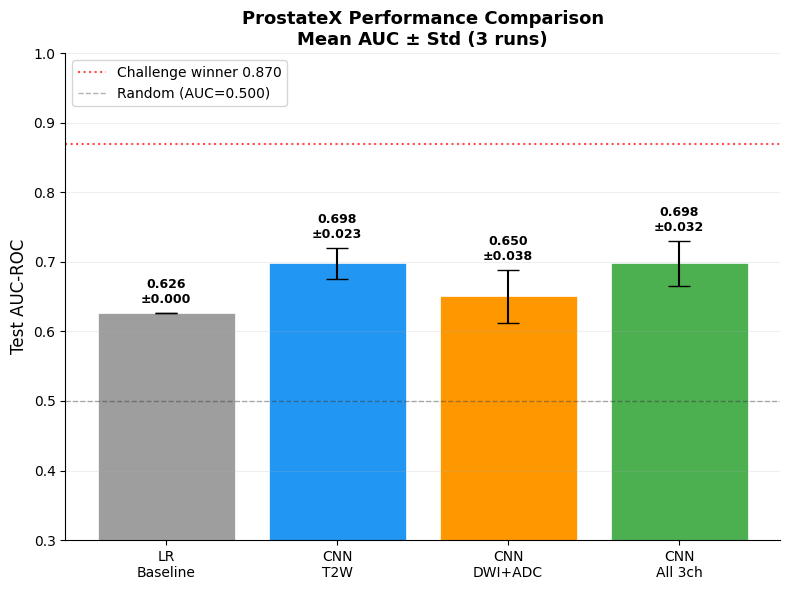

Saved: performance_comparison.png


In [19]:
# ── Figure 2: Model Performance Comparison (Mean AUC) ────────────────────────
colors_map = {
    'Baseline (LR, T2W)':  '#9E9E9E',
    'CNN: T2W':             '#2196F3',
    'CNN: DWI+ADC':         '#FF9800',
    'CNN: T2W+ADC+DWI':     '#4CAF50',
}

# Create a single plot instead of subplots
fig, ax = plt.subplots(figsize=(8, 6))

names = list(results.keys())
means = [results[n]['mean_auc'] for n in names]
stds  = [results[n]['std_auc']  for n in names]

# Plot bars with error caps
bars = ax.bar(range(len(names)), means, yerr=stds,
              color=[colors_map[n] for n in names],
              capsize=8, edgecolor='white', linewidth=0.5)

# Benchmark lines
ax.axhline(0.87, color='red', linestyle=':', linewidth=1.5, alpha=0.7,
           label='Challenge winner 0.870')
ax.axhline(0.50, color='black', linestyle='--', linewidth=1, alpha=0.3,
           label='Random (AUC=0.500)')

# Formatting
ax.set_xticks(range(len(names)))
ax.set_xticklabels(['LR\nBaseline', 'CNN\nT2W', 'CNN\nDWI+ADC', 'CNN\nAll 3ch'], fontsize=10)
ax.set_ylabel('Test AUC-ROC', fontsize=12)
ax.set_title(f'ProstateX Performance Comparison\nMean AUC ± Std ({N_RUNS} runs)', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0.3, 1.0)
ax.grid(True, axis='y', alpha=0.2)
ax.legend(loc='upper left', fontsize=10)

# Aesthetic cleanup: remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add text labels on top of bars
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.01,
            f'{m:.3f}\n±{s:.3f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: performance_comparison.png")

## 8. Final Results Table

In [17]:
# ── Full summary table with all 3 runs + mean ± std ────────────────────────
from sklearn.metrics import confusion_matrix

def youden_sens_spec(trues, preds):
    fpr, tpr, thresholds = roc_curve(trues, preds)
    bt = thresholds[np.argmax(tpr - fpr)]
    bp = (preds >= bt).astype(int)
    tn, fp, fn, tp = confusion_matrix(trues, bp).ravel()
    return tp/(tp+fn), tn/(tn+fp)

W = 100
print("=" * W)
print("FINAL RESULTS — ProstateX Clinical Significance Classification")
print(f"Metrics: AUC-ROC (primary) | Average Precision / AP (secondary) | {N_RUNS} runs each")
print("=" * W)
print(f"{'Model':<28} {'Run 1 AUC':>10} {'Run 2 AUC':>10} {'Run 3 AUC':>10} "
      f"{'Mean AUC':>10} {'Std':>6}  {'Mean AP':>8} {'Sens':>6} {'Spec':>6}")
print("-" * W)

best_auc = max(r['mean_auc'] for r in results.values())

for name, r in results.items():
    runs_str = "  ".join(f"{a:.3f}" for a in r['auc_runs'])
    s, sp    = youden_sens_spec(r['trues'], r['avg_preds'])
    marker   = " ◄" if r['mean_auc'] == best_auc else ""
    print(f"{name:<28} {runs_str}   "
          f"{r['mean_auc']:>8.3f}  {r['std_auc']:>5.3f}  "
          f"{r['mean_ap']:>7.3f}  {s:>5.3f}  {sp:>5.3f}{marker}")

print("-" * W)
print(f"{'Challenge winner (2017)':<28} {'':>10} {'':>10} {'':>10} {'0.870':>10}")
print("=" * W)

# ── Per-run detail table (AP) ────────────────────────────────────────────────
print()
print("=" * 70)
print("AVERAGE PRECISION — per run")
print("=" * 70)
print(f"{'Model':<28} {'Run 1 AP':>10} {'Run 2 AP':>10} {'Run 3 AP':>10} {'Mean AP':>10} {'Std':>6}")
print("-" * 70)
for name, r in results.items():
    ap_str = "  ".join(f"{a:.3f}" for a in r['ap_runs'])
    print(f"{name:<28} {ap_str}   {r['mean_ap']:>8.3f}  {r['std_ap']:>5.3f}")
print("=" * 70)

# ── Key findings ─────────────────────────────────────────────────────────────
best_cnn = max([k for k in results if k.startswith('CNN')], key=lambda k: results[k]['mean_auc'])
lr_auc   = results['Baseline (LR, T2W)']['mean_auc']
best_auc_val = results[best_cnn]['mean_auc']
best_ap_val  = results[best_cnn]['mean_ap']

std_auc_best = results[best_cnn]['std_auc']
std_ap_best  = results[best_cnn]['std_ap']
std_all      = results['CNN: T2W+ADC+DWI']['std_auc']
gain         = best_auc_val - lr_auc
t2_auc       = results['CNN: T2W']['mean_auc']
dwi_auc      = results['CNN: DWI+ADC']['mean_auc']
all_auc      = results['CNN: T2W+ADC+DWI']['mean_auc']
print(f"KEY FINDINGS:")
print(f"  1. Best model: {best_cnn}")
print(f"       Mean AUC = {best_auc_val:.3f} +/- {std_auc_best:.3f}")
print(f"       Mean AP  = {best_ap_val:.3f} +/- {std_ap_best:.3f}")
print(f"  2. LR baseline AUC={lr_auc:.3f}  |  CNN gain: {gain:+.3f}")
print(f"  3. Modality contribution (mean AUC, {N_RUNS} runs):")
print(f"       T2W only = {t2_auc:.3f}  DWI+ADC = {dwi_auc:.3f}  All 3ch = {all_auc:.3f}")
print(f"  4. AUC-ROC vs AP: AP penalises FP more heavily under 23% positive imbalance.")
print(f"     Reporting both gives a more complete picture of classifier quality.")
print(f"  5. Run-to-run std (T2W+ADC+DWI AUC std={std_all:.3f}) reflects small test set (~50 patches).")


FINAL RESULTS — ProstateX Clinical Significance Classification
Metrics: AUC-ROC (primary) | Average Precision / AP (secondary) | 3 runs each
Model                         Run 1 AUC  Run 2 AUC  Run 3 AUC   Mean AUC    Std   Mean AP   Sens   Spec
----------------------------------------------------------------------------------------------------
Baseline (LR, T2W)           0.626  0.626  0.626      0.626  0.000    0.341  0.833  0.488
CNN: T2W                     0.720  0.667  0.707      0.698  0.023    0.306  1.000  0.439 ◄
CNN: DWI+ADC                 0.618  0.630  0.703      0.650  0.038    0.201  0.833  0.683
CNN: T2W+ADC+DWI             0.663  0.740  0.691      0.698  0.032    0.311  0.667  0.756
----------------------------------------------------------------------------------------------------
Challenge winner (2017)                                            0.870

AVERAGE PRECISION — per run
Model                          Run 1 AP   Run 2 AP   Run 3 AP    Mean AP    Std
---------

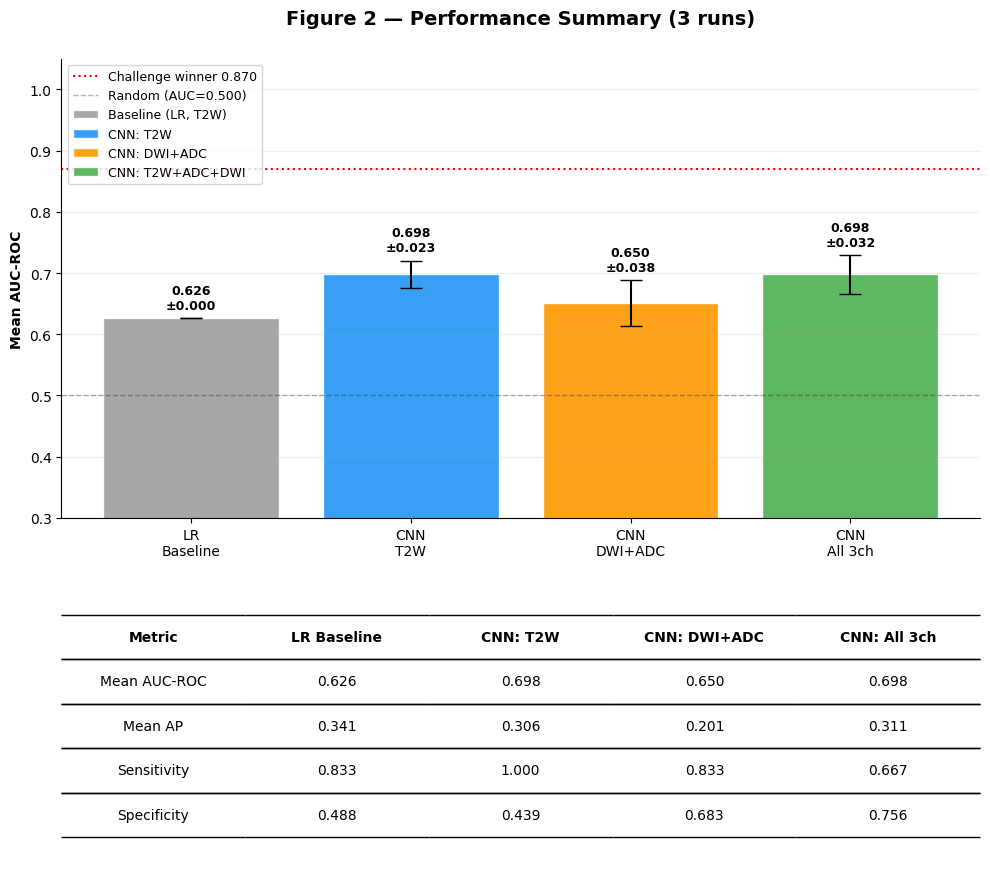

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract dynamic labels and colors
names = list(results.keys())
colors = [colors_map[n] for n in names]

# 2. Setup the figure and GridSpec
fig = plt.figure(figsize=(10, 9)) # Slightly taller to accommodate legend/table
gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 1])

# --- Upper Plot: Bar Chart ---
ax_bar = fig.add_subplot(gs[0])
means = [results[n]['mean_auc'] for n in names]
stds  = [results[n]['std_auc']  for n in names]

# Plot bars individually to assign labels for the legend
for i, (name, mean, std, color) in enumerate(zip(names, means, stds, colors)):
    ax_bar.bar(i, mean, yerr=std, color=color, capsize=8, 
               edgecolor='white', alpha=0.9, label=name)

# Benchmark lines
ax_bar.axhline(0.87, color='red', linestyle=':', linewidth=1.5, label='Challenge winner 0.870')
ax_bar.axhline(0.50, color='black', linestyle='--', linewidth=1, alpha=0.3, label='Random (AUC=0.500)')

# Formatting
ax_bar.set_ylabel('Mean AUC-ROC', fontweight='bold')
ax_bar.set_title(f'Figure 2 — Performance Summary ({N_RUNS} runs)', fontsize=14, fontweight='bold', pad=25)
ax_bar.set_ylim(0.3, 1.05) # Extra room for labels
ax_bar.set_xticks(range(len(names)))
ax_bar.set_xticklabels(['LR\nBaseline', 'CNN\nT2W', 'CNN\nDWI+ADC', 'CNN\nAll 3ch'], fontsize=10)

# Legend Configuration
# Placing it outside to the right or inside at the top
ax_bar.legend(loc='upper left', fontsize=9, frameon=True, facecolor='white', framealpha=0.8)

# Aesthetic cleanup
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.grid(True, axis='y', alpha=0.2)

# Add value labels on top of bars
for i, (m, s) in enumerate(zip(means, stds)):
    ax_bar.text(i, m + s + 0.01, f'{m:.3f}\n±{s:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Lower Plot: Dynamic Table ---
ax_table = fig.add_subplot(gs[1])
ax_table.axis('off')

header = ["Metric", "LR Baseline", "CNN: T2W", "CNN: DWI+ADC", "CNN: All 3ch"]
table_data = [header]
row_labels = ["Mean AUC-ROC", "Mean AP", "Sensitivity", "Specificity"]
rows = {label: [] for label in row_labels}

for n in names:
    r = results[n]
    s, sp = youden_sens_spec(r['trues'], r['avg_preds'])
    rows["Mean AUC-ROC"].append(f"{r['mean_auc']:.3f}")
    rows["Mean AP"].append(f"{r['mean_ap']:.3f}")
    rows["Sensitivity"].append(f"{s:.3f}")
    rows["Specificity"].append(f"{sp:.3f}")

for label in row_labels:
    table_data.append([label] + rows[label])

table = ax_table.table(cellText=table_data, loc='center', cellLoc='center', edges='horizontal')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2) 

for j in range(len(header)):
    table[(0, j)].get_text().set_weight('bold')

plt.tight_layout()
plt.savefig('results_with_legend.png', dpi=150, bbox_inches='tight')
plt.show()